# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [86]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [87]:
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''
print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



## New Corpus For Camparing 

In [88]:
new_corpus = '''
Celebal Technologies is a software and technology company based in Jaipur, India. 
The company helps businesses solve problems using data, cloud computing, 
artificial intelligence, and modern software solutions. It works with many 
organizations across different industries and helps them improve their business with technology.

One of the main areas at Celebal Technologies is Data Engineering. Data engineers 
collect data from different systems, clean it, and prepare it for analysis. 
They also build data pipelines that move data from one place to another. 
These pipelines help companies work with large amounts of data in a fast and reliable way.

The company uses technologies like Python, SQL, Apache Spark, Azure Data Factory, 
Databricks, and Microsoft Azure. These tools help developers process data, build 
cloud applications, and create scalable business solutions. Teams choose different 
tools depending on the project requirements.

Celebal Technologies also works on Artificial Intelligence and Machine Learning projects. 
Data scientists use clean data to train machine learning models. 
These models can predict sales, detect unusual activities, recommend products, 
and support business decisions. The company also builds AI chatbots using 
Large Language Models to answer customer questions and automate daily tasks.

Business Intelligence is another important service. The company creates dashboards 
using Microsoft Power BI. These dashboards show business data with charts, tables, and reports. 
Managers use them to understand business performance and make better decisions.

Cloud Computing plays a major role in many projects. Celebal Technologies mainly 
works with Microsoft Azure and Amazon Web Services. Cloud platforms help businesses 
store data securely, run applications, and increase resources whenever needed. 
Cloud technology also makes systems more flexible and easier to manage.

The company follows modern software development practices. Developers use Git for 
version control and Agile methods to manage projects. Teams work together to build 
reliable applications and deliver projects on time. Testing and code reviews are 
also an important part of the development process.

Celebal Technologies serves customers from many industries such as banking, 
healthcare, manufacturing, retail, education, and energy. Every customer has 
different business needs, so the company builds solutions according to their requirements.

Learning is an important part of the company culture. Employees regularly 
attend technical training sessions, workshops, and certification programs. 
This helps them stay updated with new technologies and improve their skills.

The company also provides internship programs for engineering students. During the internship, 
students work on real projects and learn technologies such as Data Engineering, Artificial 
Intelligence, Cloud Computing, and Web Development. They receive guidance from experienced 
mentors and gain practical experience.

Security is considered in every project. The company follows good practices to protect 
customer data by using secure authentication, encryption, and access control. These 
practices help keep business information safe.

Today, Celebal Technologies continues to build modern digital solutions for businesses 
around the world. By combining cloud computing, data engineering, artificial intelligence, 
and business intelligence, the company helps organizations improve their performance and 
make better business decisions.
'''

print(new_corpus)


Celebal Technologies is a software and technology company based in Jaipur, India. 
The company helps businesses solve problems using data, cloud computing, 
artificial intelligence, and modern software solutions. It works with many 
organizations across different industries and helps them improve their business with technology.

One of the main areas at Celebal Technologies is Data Engineering. Data engineers 
collect data from different systems, clean it, and prepare it for analysis. 
They also build data pipelines that move data from one place to another. 
These pipelines help companies work with large amounts of data in a fast and reliable way.

The company uses technologies like Python, SQL, Apache Spark, Azure Data Factory, 
Databricks, and Microsoft Azure. These tools help developers process data, build 
cloud applications, and create scalable business solutions. Teams choose different 
tools depending on the project requirements.

Celebal Technologies also works on Artificial I

# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [89]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 37
X shape: (35, 7)
y shape: (35,)


## Tokenization For New Corpus

In [90]:
new_tokenizer = Tokenizer()
new_tokenizer.fit_on_texts([new_corpus])

new_total_words = len(new_tokenizer.word_index) + 1
print("Vocabulary size:", new_total_words)

new_input_sequences = []
for line in new_corpus.split('\n'):
    new_token_list = new_tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(new_token_list)):
        n_gram_seq = new_token_list[:i+1]
        new_input_sequences.append(n_gram_seq)

new_max_len = max(len(seq) for seq in new_input_sequences)
new_input_sequences = pad_sequences(new_input_sequences, maxlen=new_max_len, padding='pre')

new_X = new_input_sequences[:, :-1]
new_y = new_input_sequences[:, -1]

print("New X shape:", new_X.shape)
print("New y shape:", new_y.shape)

Vocabulary size: 232
New X shape: (439, 15)
New y shape: (439,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [91]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training completed")
print("Accuracy Vanilla RNN:", rnn_history.history['accuracy'][-1])
print("Loss Vanilla RNN:", rnn_history.history['loss'][-1])

Vanilla RNN training completed
Accuracy Vanilla RNN: 0.8571428656578064
Loss Vanilla RNN: 0.8370118141174316


## Updated Vanilla RNN

In [92]:
updated_rnn_model = Sequential([
    Embedding(new_total_words, 64, input_length=new_max_len-1),
    SimpleRNN(128),
    Dense(new_total_words, activation='softmax')
])

updated_rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

updated_rnn_history = updated_rnn_model.fit(new_X, new_y, epochs=200, verbose=0)
print("Updated Vanilla RNN training completed")
print("Accuracy Updated Vanilla RNN:", updated_rnn_history.history['accuracy'][-1])
print("Loss Updated Vanilla RNN:", updated_rnn_history.history['loss'][-1])

Updated Vanilla RNN training completed
Accuracy Updated Vanilla RNN: 0.9794988632202148
Loss Updated Vanilla RNN: 0.0441264882683754


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [93]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")
print("Accuracy LSTM:", lstm_history.history['accuracy'][-1])
print("Loss LSTM:", lstm_history.history['loss'][-1])

LSTM training completed
Accuracy LSTM: 0.6857143044471741
Loss LSTM: 1.3882750272750854


## Updated LSTM

In [94]:
updated_lstm_model = Sequential([
    Embedding(new_total_words, 64, input_length=new_max_len-1),
    LSTM(128),
    Dense(new_total_words, activation='softmax')
])

updated_lstm_model.compile(loss='sparse_categorical_crossentropy',
                           optimizer='adam',
                           metrics=['accuracy'])

updated_lstm_history = updated_lstm_model.fit(new_X, new_y, epochs=200, verbose=0)
print("Updated LSTM training completed")
print("Accuracy Updated LSTM:", updated_lstm_history.history['accuracy'][-1])
print("Loss Updated LSTM:", updated_lstm_history.history['loss'][-1])

Updated LSTM training completed
Accuracy Updated LSTM: 0.9772209525108337
Loss Updated LSTM: 0.05625860393047333


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [95]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")
print("Accuracy GRU:", gru_history.history['accuracy'][-1])
print("Loss GRU:", gru_history.history['loss'][-1])

GRU training completed
Accuracy GRU: 0.7714285850524902
Loss GRU: 1.2864656448364258


## Updated GRU

In [96]:
updated_gru_model = Sequential([
    Embedding(new_total_words, 64, input_length=new_max_len-1),
    GRU(128),
    Dense(new_total_words, activation='softmax')
])

updated_gru_model.compile(loss='sparse_categorical_crossentropy',
                          optimizer='adam',
                          metrics=['accuracy'])

updated_gru_history = updated_gru_model.fit(new_X, new_y, epochs=200, verbose=0)
print("Updated GRU training completed")
print("Accuracy Updated GRU:", updated_gru_history.history['accuracy'][-1])
print("Loss Updated GRU:", updated_gru_history.history['loss'][-1])

Updated GRU training completed
Accuracy Updated GRU: 0.9703872203826904
Loss Updated GRU: 0.043527428060770035


## 📉 Compare Training Loss

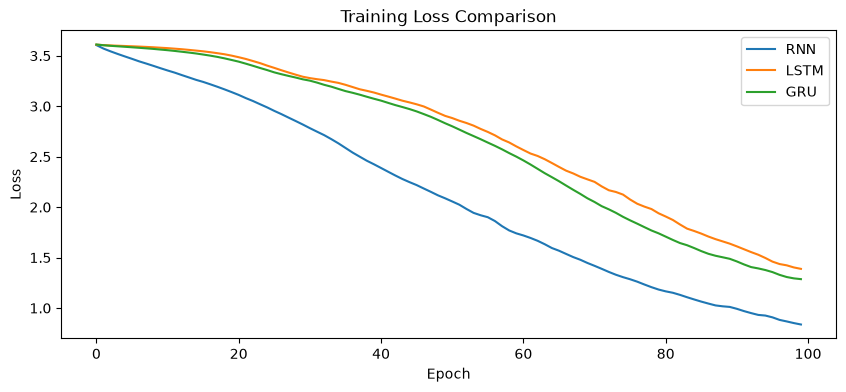

In [97]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

## Camparing the Updated Models Loss

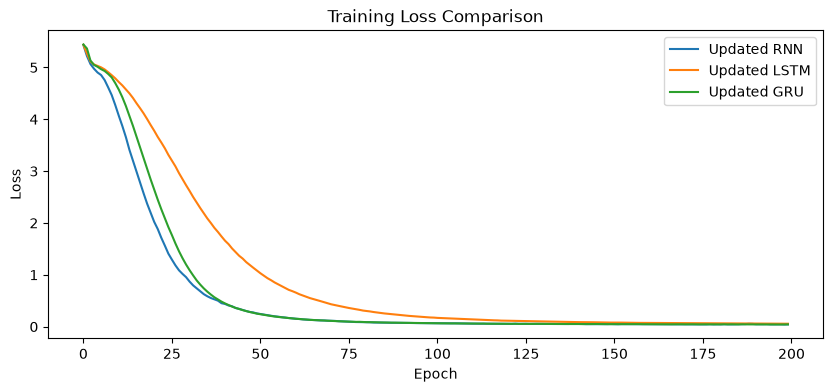

In [98]:
plt.figure(figsize=(10,4))
plt.plot(updated_rnn_history.history['loss'], label='Updated RNN')
plt.plot(updated_lstm_history.history['loss'], label='Updated LSTM')
plt.plot(updated_gru_history.history['loss'], label='Updated GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [99]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

In [100]:
def new_generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = new_tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=new_max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in new_tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [101]:
print("RNN :", generate_text(rnn_model, "deep learning", 5))
print("LSTM:", generate_text(lstm_model, "deep learning", 5))
print("GRU :", generate_text(gru_model, "deep learning", 5))

RNN : deep learning models can generate meaningful sentences
LSTM: deep learning learning models generate meaningful sentences
GRU : deep learning is models predict the the


## Updated Models Genrating the Tetx

In [102]:
print("RNN :", new_generate_text(updated_rnn_model, "Celebal Technologies", 10))
print("LSTM:", new_generate_text(updated_lstm_model, "Celebal Technologies", 10))
print("GRU :", new_generate_text(updated_gru_model, "Celebal Technologies", 10))

RNN : Celebal Technologies also works on artificial intelligence and machine learning projects from
LSTM: Celebal Technologies is a software and technology company based in jaipur india
GRU : Celebal Technologies is a software and technology company based in jaipur india


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**